In [5]:
import nibabel as nib
import numpy as np
import glob

import matplotlib.pyplot as plt
#from tensorflow.keras.utils import to_categorical

from sklearn.preprocessing import MinMaxScaler
scaler=MinMaxScaler()

In [9]:
Train_dataset_path="Brain_T_Segmented/BraTS2020_TrainingData/MICCAI_BraTS2020_TrainingData/"

In [14]:
img_flair=nib.load(Train_dataset_path+"BraTS20_Training_018/BraTS20_Training_018_flair.nii").get_fdata()

In [15]:
img_flair.shape

(240, 240, 155)

In [18]:
img_flair.max()#need scalling

707.0

In [19]:
img_flair=scaler.fit_transform(img_flair.reshape(-1,img_flair.shape[-1])).reshape(img_flair.shape)

In [20]:
img_flair.shape


(240, 240, 155)

In [21]:
img_flair.max()

1.0

In [22]:
img_seg=nib.load(Train_dataset_path+"BraTS20_Training_018/BraTS20_Training_018_seg.nii").get_fdata()

In [23]:
img_seg

memmap([[[0., 0., 0., ..., 0., 0., 0.],
         [0., 0., 0., ..., 0., 0., 0.],
         [0., 0., 0., ..., 0., 0., 0.],
         ...,
         [0., 0., 0., ..., 0., 0., 0.],
         [0., 0., 0., ..., 0., 0., 0.],
         [0., 0., 0., ..., 0., 0., 0.]],

        [[0., 0., 0., ..., 0., 0., 0.],
         [0., 0., 0., ..., 0., 0., 0.],
         [0., 0., 0., ..., 0., 0., 0.],
         ...,
         [0., 0., 0., ..., 0., 0., 0.],
         [0., 0., 0., ..., 0., 0., 0.],
         [0., 0., 0., ..., 0., 0., 0.]],

        [[0., 0., 0., ..., 0., 0., 0.],
         [0., 0., 0., ..., 0., 0., 0.],
         [0., 0., 0., ..., 0., 0., 0.],
         ...,
         [0., 0., 0., ..., 0., 0., 0.],
         [0., 0., 0., ..., 0., 0., 0.],
         [0., 0., 0., ..., 0., 0., 0.]],

        ...,

        [[0., 0., 0., ..., 0., 0., 0.],
         [0., 0., 0., ..., 0., 0., 0.],
         [0., 0., 0., ..., 0., 0., 0.],
         ...,
         [0., 0., 0., ..., 0., 0., 0.],
         [0., 0., 0., ..., 0., 0., 0.],
    

In [25]:
img_seg=img_seg.astype(np.uint8)
img_seg

memmap([[[0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],
         ...,
         [0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0]],

        [[0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],
         ...,
         [0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0]],

        [[0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],
         ...,
         [0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0]],

        ...,

        [[0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],
         ...,
         [0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0]],

        [[0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],
    

In [26]:
np.unique(img_seg)

array([0, 1, 2, 4], dtype=uint8)

In [27]:
img_seg[img_seg==4]=3

In [28]:
np.unique(img_seg)

array([0, 1, 2, 3], dtype=uint8)

In [29]:
img_seg.shape

(240, 240, 155)

NameError: name 'test_image_t2' is not defined

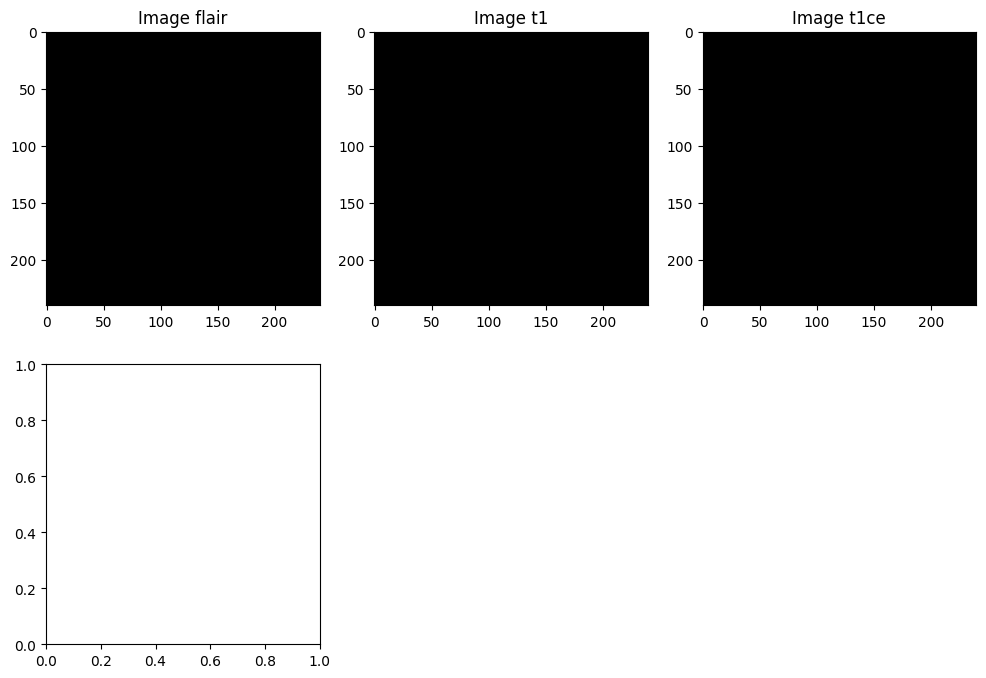

In [30]:
import random
n_slice=random.randint(0, img_seg.shape[2])

plt.figure(figsize=(12, 8))

plt.subplot(231)
plt.imshow(img_flair[:,:,n_slice], cmap='gray')
plt.title('Image flair')
plt.subplot(232)
plt.imshow(img_flair[:,:,n_slice], cmap='gray')
plt.title('Image t1')
plt.subplot(233)
plt.imshow(img_flair[:,:,n_slice], cmap='gray')
plt.title('Image t1ce')
plt.subplot(234)
plt.imshow(test_image_t2[:,:,n_slice], cmap='gray')
plt.title('Image t2')
plt.subplot(235)
plt.imshow(test_mask[:,:,n_slice])
plt.title('Mask')
plt.show()